### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

In [86]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder

In [4]:
from imblearn.over_sampling import RandomOverSampler
from feature_engine.selection import SmartCorrelatedSelection

In [101]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications.efficientnet import EfficientNetB7

In [98]:
AUTO = tf.data.experimental.AUTOTUNE

### Step 2: Load Data

In [6]:
images = glob('./data/SkinCancer/train/*/*.jpg')

In [7]:
len(images)

2637

In [13]:
images = [path.replace('\\','/') for path in images]
labels = [path.split('/')[-2] for path in images]

In [16]:
df = pd.DataFrame({'filepath': images, 'label': labels})

In [17]:
df.head()

,filepath,label
0,./data/SkinCancer/train/benign/100.jpg,benign
1,./data/SkinCancer/train/benign/1000.jpg,benign
2,./data/SkinCancer/train/benign/1001.jpg,benign
3,./data/SkinCancer/train/benign/1002.jpg,benign
4,./data/SkinCancer/train/benign/1004.jpg,benign


### Step 3: Exploaring Data

Target Distribution

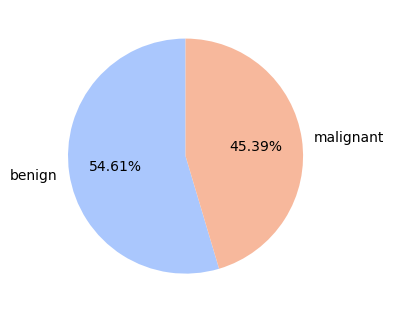

In [20]:
plt.figure(figsize=(4, 4))
plt.pie(
    df['label'].value_counts(),
    autopct='%.2f%%',
    labels=df['label'].value_counts().index,
    colors=sns.color_palette('coolwarm', 2),
    startangle=90
)
plt.tight_layout()

Preview Images

In [84]:
def PreviewImage(category, num=4):
    height = np.ceil(num / 4).astype(np.int16)
    width = 4 if num >= 4 else num
    fig = plt.figure(figsize=(4*width, 4*height))
    temp = df[df['label'] == category]

    for i in range(num):
        image_path = temp.sample()['filepath'].values[0]
        img = plt.imread(image_path)
        plt.subplot(height, 4, i+1)
        plt.imshow(img)
        plt.axis('off')
    fig.suptitle(f'Image for {category} category', fontsize=width*4)
    plt.tight_layout()

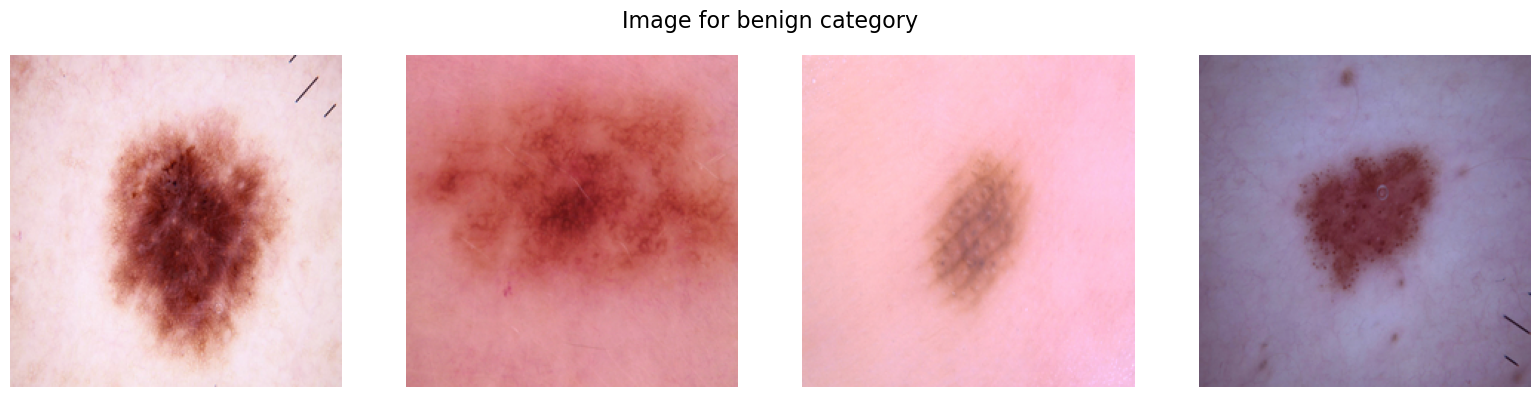

In [83]:
PreviewImage('benign', 4)

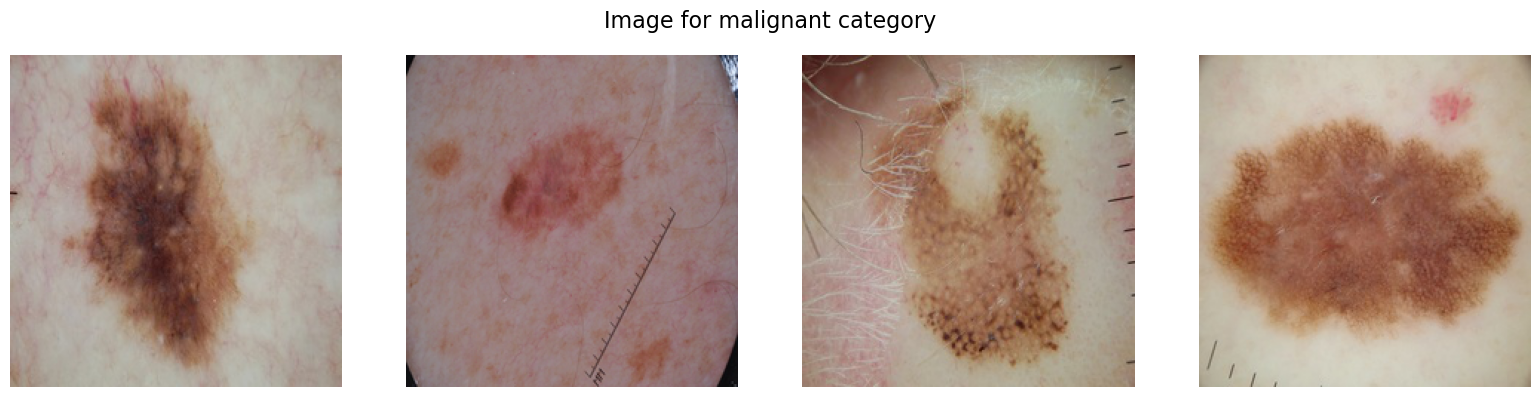

In [85]:
PreviewImage('malignant', 4)

### Step 4: Feature Engineering

Label Encoding

In [87]:
le = LabelEncoder()

In [89]:
df['label_bin'] = le.fit_transform(df['label'])

### Step 5: Preparing Data

Split Data

In [91]:
X_train, X_test, y_train, y_test = train_test_split(
    df['filepath'],
    df['label_bin'],
    test_size=0.2,
    random_state=42
)

Decode Image

In [97]:
def decode_image(filepath, label=None):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img)
    img = tf.image.resize(img, [224, 224])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

Create Datasets

In [99]:
train_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_train, y_train))
    .map(decode_image, num_parallel_calls=AUTO)
    .batch(32)
    .prefetch(AUTO)
)

In [100]:
test_ds = (
    tf.data.Dataset
    .from_tensor_slices((X_test, y_test))
    .map(decode_image, num_parallel_calls=AUTO)
    .batch(32)
    .prefetch(AUTO)
)

### Step 6: Model Development

In [102]:
pre_trained_model = EfficientNetB7(
    input_shape=(224, 224, 3),
    weights='imagenet',
    include_top=False
)

258076736/258076736 ━━━━━━━━━━━━━━━━━━━━ 387s 2us/step


In [106]:
for layer in pre_trained_model.layers:
    layer.trainable = False

In [108]:
inputs = layers.Input(shape=(224, 224, 3))
x = pre_trained_model(inputs, training=False)
x = layers.Flatten()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
x = layers.BatchNormalization()(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

In [110]:
model.compile(
    loss='Crossentropy',
    optimizer='adam',
    metrics=['AUC']
)

In [111]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5,
    verbose=1
)

Epoch 1/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - AUC: 0.5021 - loss: 0.8091 - val_AUC: 0.5000 - val_loss: 2.3430
Epoch 2/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - AUC: 0.4773 - loss: 0.7896 - val_AUC: 0.5003 - val_loss: 1.0943
Epoch 3/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - AUC: 0.4829 - loss: 0.7736 - val_AUC: 0.6291 - val_loss: 0.7471
Epoch 4/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - AUC: 0.5142 - loss: 0.7334 - val_AUC: 0.4959 - val_loss: 0.6907
Epoch 5/5
66/66 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - AUC: 0.5009 - loss: 0.7409 - val_AUC: 0.5486 - val_loss: 0.9220


In [112]:
hist_df = pd.DataFrame(history.history)

In [113]:
hist_df

,AUC,loss,val_AUC,val_loss
0,0.502128,0.809103,0.500000,2.342952
1,0.477279,0.789557,0.500274,1.094268
2,0.482861,0.773606,0.629055,0.747094
3,0.514193,0.733383,0.495918,0.690662
4,0.500945,0.740929,0.548583,0.922007


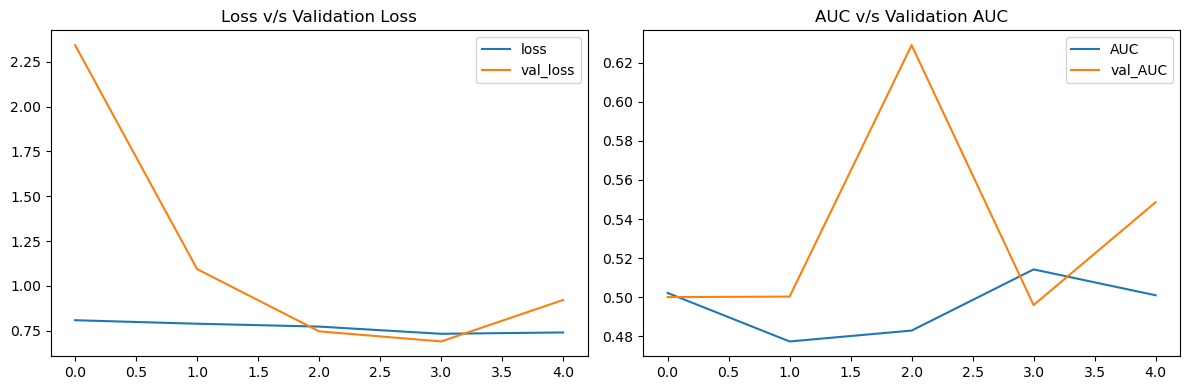

In [119]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
hist_df['loss'].plot()
hist_df['val_loss'].plot()
plt.title('Loss v/s Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
hist_df['AUC'].plot()
hist_df['val_AUC'].plot()
plt.title('AUC v/s Validation AUC')
plt.legend()

plt.tight_layout()